# Lesson 2.1 — 2D Scalar Transport

## From 1D to 2D: Adding a Second Dimension

Imagine dropping a dye blob into a river that flows diagonally. The blob drifts with
the current (advection in both $x$ and $y$) and simultaneously spreads outward (diffusion
in both directions). The **2D advection-diffusion equation** describes this:

$$\frac{\partial u}{\partial t} + c_x \frac{\partial u}{\partial x} + c_y \frac{\partial u}{\partial y} = \alpha \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

Everything from Module 1 generalises directly — just apply the same 1D stencils in each
spatial direction. The only new complexity is the 2D array indexing and boundary conditions
on all four sides.

---

## 2D Grid and Indexing Convention

The standard convention in this curriculum:

```
u[j, i]  →  position (x_i, y_j)
j = row index    → y direction  (axis 0)
i = column index → x direction  (axis 1)
```

Stencil in 2D:
- Right neighbour: `u[j, i+1]` → `u[j, 2:]`
- Left neighbour:  `u[j, i-1]` → `u[j, :-2]`
- Top neighbour:   `u[j+1, i]` → `u[2:, j]` → `u[2:, :]`
- Bottom neighbour:`u[j-1, i]` → `u[:-2, :]`

---

## CFL Condition in 2D

The 2D CFL condition requires stability in *each direction*:

$$\nu_x = \frac{c_x \Delta t}{\Delta x} \leq 1, \qquad \nu_y = \frac{c_y \Delta t}{\Delta y} \leq 1$$

In practice, use: $\Delta t \leq \frac{1}{|c_x|/\Delta x + |c_y|/\Delta y}$

---

## Operator Splitting (Strang Splitting)

A clean way to extend 1D schemes to 2D: solve each direction separately in alternating half-steps.

$$u^{n+1} = L_y^{\Delta t/2} \circ L_x^{\Delta t} \circ L_y^{\Delta t/2} \, u^n$$

This is **Strang splitting** — second-order accurate despite using 1D solvers as building blocks.
Used in many production CFD codes for operator simplicity.


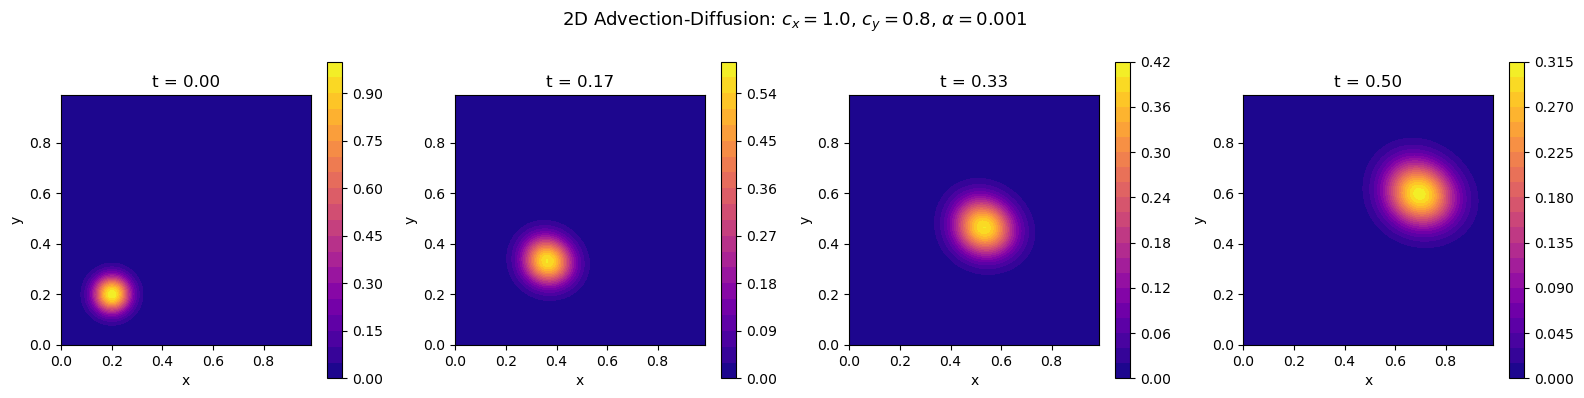

dt = 0.002358  |  CFL_x = 0.189  |  CFL_y = 0.151


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 2D advection-diffusion: explicit upwind + central diffusion

nx, ny = 80, 80
Lx, Ly = 1.0, 1.0
dx = Lx / nx
dy = Ly / ny
x  = np.linspace(0, Lx, nx, endpoint=False)
y  = np.linspace(0, Ly, ny, endpoint=False)
X, Y = np.meshgrid(x, y)

cx, cy = 1.0, 0.8  # advection velocities
alpha  = 1e-3       # diffusivity

# Stable time step
dt = 0.4 / (abs(cx)/dx + abs(cy)/dy + 2*alpha*(1/dx**2 + 1/dy**2))

# Initial condition: Gaussian blob at (0.2, 0.2)
u = np.exp(-((X - 0.2)**2 + (Y - 0.2)**2) / 0.005)

T  = 0.5
nt = int(T / dt)

# Snapshot times
snapshots = []
snap_times = [0, T/3, 2*T/3, T]
snap_steps = [int(t/dt) for t in snap_times]
step = 0

snapshots.append(u.copy())

for n in range(nt):
    u_old = u.copy()
    
    # Upwind advection in x
    u[1:-1, 1:-1] -= dt * cx/dx * (u_old[1:-1, 1:-1] - u_old[1:-1, :-2])
    # Upwind advection in y
    u[1:-1, 1:-1] -= dt * cy/dy * (u_old[1:-1, 1:-1] - u_old[:-2, 1:-1])
    # Diffusion: central
    u[1:-1, 1:-1] += dt * alpha * (
        (u_old[1:-1, 2:] - 2*u_old[1:-1, 1:-1] + u_old[1:-1, :-2]) / dx**2 +
        (u_old[2:, 1:-1] - 2*u_old[1:-1, 1:-1] + u_old[:-2, 1:-1]) / dy**2
    )
    # Periodic BCs
    u[0,  :] = u[-2, :]
    u[-1, :] = u[1,  :]
    u[:,  0] = u[:, -2]
    u[:, -1] = u[:,  1]
    
    step += 1
    if step in snap_steps[1:]:
        snapshots.append(u.copy())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, snap, t in zip(axes, snapshots, snap_times):
    cf = ax.contourf(X, Y, snap, levels=20, cmap='plasma', vmin=0)
    plt.colorbar(cf, ax=ax)
    ax.set_title(f't = {t:.2f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.suptitle(f'2D Advection-Diffusion: $c_x={cx}$, $c_y={cy}$, $\\alpha={alpha}$', fontsize=13)
plt.tight_layout()
plt.show()

print(f"dt = {dt:.6f}  |  CFL_x = {cx*dt/dx:.3f}  |  CFL_y = {cy*dt/dy:.3f}")

## Boundary Conditions in 2D

| BC type | Description | Implementation |
|---------|-------------|----------------|
| Dirichlet | Prescribed value at boundary | Set `u[0,:] = value` directly |
| Neumann | Prescribed gradient (e.g., zero flux) | `u[0,:] = u[1,:]` (zero gradient) |
| Periodic | Domain wraps around | `u[0,:] = u[-2,:]`, `u[-1,:] = u[1,:]` |
| Outflow | Value advects out, no reflection | Upwind: extrapolate `u[-1,:] = u[-2,:]` |

## Key Takeaways

- 2D transport is a direct extension of 1D — apply 1D stencils in each spatial direction.
- The 2D CFL condition combines the constraints from all directions.
- Operator splitting (Strang) achieves 2nd-order accuracy using 1D sweeps.
- Boundary conditions must be applied on all four sides — easy to miss in the code!

---

**Next**: Lesson 2.2 — Finite Volume Method: flux balance on control volumes.
